In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import joblib

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style("whitegrid")

print("✓ Imports successful")


✓ Imports successful


In [2]:
print("="*60)
print("LOADING DATA AND MODELS")
print("="*60)

# Load clean data
X_train = np.load('../data/processed/X_train.npy')
X_test = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test = np.load('../data/processed/y_test.npy')

print(f"✓ Training set: {X_train.shape}")
print(f"✓ Test set: {X_test.shape}")

# Load baseline XGBoost
xgb_model = joblib.load('../models/base_classifier/xgboost_baseline.pkl')
xgb_baseline_acc = accuracy_score(y_test, xgb_model.predict(X_test))

print(f"\n✓ XGBoost loaded - Baseline accuracy: {xgb_baseline_acc:.4f}")

# Load adversarial examples
X_test_fgsm = np.load('../data/adversarial/X_test_fgsm.npy')
X_test_pgd = np.load('../data/adversarial/X_test_pgd.npy')
X_test_cw = np.load('../data/adversarial/X_test_cw.npy')

print("\n✓ Adversarial examples loaded:")
print(f"  FGSM: {X_test_fgsm.shape}")
print(f"  PGD:  {X_test_pgd.shape}")
print(f"  C&W:  {X_test_cw.shape}")


LOADING DATA AND MODELS
✓ Training set: (831892, 41)
✓ Test set: (207974, 41)

✓ XGBoost loaded - Baseline accuracy: 0.9998

✓ Adversarial examples loaded:
  FGSM: (207974, 41)
  PGD:  (207974, 41)
  C&W:  (207974, 41)


In [3]:
print("\n" + "="*60)
print("CROSS-MODEL TRANSFER ATTACK")
print("="*60)

print("""
Transfer Attack Concept:

Normal Attack Scenario:
  1. Attacker generates adversarial examples for Model A
  2. Tests them on Model A
  3. Attack succeeds on Model A

Transfer Attack Scenario:
  1. Attacker generates adversarial examples for Model A (XGBoost)
  2. Tests them on Models B, C, D (Random Forest, Neural Net, Logistic Regression)
  3. Question: Do attacks transfer across architectures?

Why This Matters:
  - Attackers often don't have access to target model
  - They train a surrogate model and generate attacks
  - If attacks transfer, they can fool ANY model
  - This is a major security vulnerability

What We'll Test:
  1. Train 3 additional models (RF, NN, LR)
  2. Test their clean accuracy
  3. Test FGSM/PGD/C&W examples on all models
  4. Calculate transfer success rates
  5. Analyze which attacks transfer best

Expected Outcome:
  - Transfer rates: 60-90% (attacks work across models)
  - Tree-based models (XGB, RF) show higher transfer
  - Deep learning vulnerability is architecture-agnostic
""")


CROSS-MODEL TRANSFER ATTACK

Transfer Attack Concept:

Normal Attack Scenario:
  1. Attacker generates adversarial examples for Model A
  2. Tests them on Model A
  3. Attack succeeds on Model A

Transfer Attack Scenario:
  1. Attacker generates adversarial examples for Model A (XGBoost)
  2. Tests them on Models B, C, D (Random Forest, Neural Net, Logistic Regression)
  3. Question: Do attacks transfer across architectures?

Why This Matters:
  - Attackers often don't have access to target model
  - They train a surrogate model and generate attacks
  - If attacks transfer, they can fool ANY model
  - This is a major security vulnerability

What We'll Test:
  1. Train 3 additional models (RF, NN, LR)
  2. Test their clean accuracy
  3. Test FGSM/PGD/C&W examples on all models
  4. Calculate transfer success rates
  5. Analyze which attacks transfer best

Expected Outcome:
  - Transfer rates: 60-90% (attacks work across models)
  - Tree-based models (XGB, RF) show higher transfer
  - D

In [4]:
print("\n" + "="*60)
print("TRAINING ALTERNATIVE MODELS")
print("="*60)

models = {}

# 1. Random Forest
print("\n1. Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_model.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf_model.predict(X_test))
models['Random Forest'] = rf_model
print(f"✓ Random Forest trained - Accuracy: {rf_acc:.4f} ({rf_acc*100:.2f}%)")

# 2. Neural Network (MLP)
print("\n2. Training Neural Network (MLP)...")
nn_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=50,
    random_state=42,
    verbose=True
)
nn_model.fit(X_train, y_train)
nn_acc = accuracy_score(y_test, nn_model.predict(X_test))
models['Neural Network'] = nn_model
print(f"✓ Neural Network trained - Accuracy: {nn_acc:.4f} ({nn_acc*100:.2f}%)")

# 3. Logistic Regression
print("\n3. Training Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
lr_model.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr_model.predict(X_test))
models['Logistic Regression'] = lr_model
print(f"✓ Logistic Regression trained - Accuracy: {lr_acc:.4f} ({lr_acc*100:.2f}%)")

# Add XGBoost to models dict
models['XGBoost'] = xgb_model

print("\n" + "="*60)
print("BASELINE ACCURACY SUMMARY")
print("="*60)

baseline_accuracies = {
    'XGBoost': xgb_baseline_acc,
    'Random Forest': rf_acc,
    'Neural Network': nn_acc,
    'Logistic Regression': lr_acc
}

for name, acc in baseline_accuracies.items():
    print(f"  {name:20s}: {acc:.4f} ({acc*100:.2f}%)")



TRAINING ALTERNATIVE MODELS

1. Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   41.8s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:  3.6min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  3.9min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    1.3s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    1.4s finished


✓ Random Forest trained - Accuracy: 0.9995 (99.95%)

2. Training Neural Network (MLP)...
Iteration 1, loss = 0.03261568
Iteration 2, loss = 0.01926913
Iteration 3, loss = 0.01598802
Iteration 4, loss = 0.01275352
Iteration 5, loss = 0.01203171
Iteration 6, loss = 0.01069808
Iteration 7, loss = 0.00987601
Iteration 8, loss = 0.00998948
Iteration 9, loss = 0.00934001
Iteration 10, loss = 0.00913710
Iteration 11, loss = 0.00884660
Iteration 12, loss = 0.00840749
Iteration 13, loss = 0.00854577
Iteration 14, loss = 0.00816730
Iteration 15, loss = 0.00780592
Iteration 16, loss = 0.00782696
Iteration 17, loss = 0.00756085
Iteration 18, loss = 0.00768586
Iteration 19, loss = 0.00733469
Iteration 20, loss = 0.00759470
Iteration 21, loss = 0.00769418
Iteration 22, loss = 0.00723829
Iteration 23, loss = 0.00700304
Iteration 24, loss = 0.00672677
Iteration 25, loss = 0.00703840
Iteration 26, loss = 0.00678189
Iteration 27, loss = 0.00703372
Iteration 28, loss = 0.00668068
Iteration 29, loss = 0.0

In [5]:
print("\n" + "="*60)
print("TESTING TRANSFER ATTACKS")
print("="*60)

# Test each adversarial example on each model
attack_datasets = {
    'FGSM': X_test_fgsm,
    'PGD': X_test_pgd,
    'C&W': X_test_cw
}

results = []

for attack_name, X_adv in attack_datasets.items():
    print(f"\n{'='*60}")
    print(f"Testing {attack_name} Transfer")
    print('='*60)
    
    for model_name, model in models.items():
        # Predict on adversarial examples
        y_pred_adv = model.predict(X_adv)
        acc_adv = accuracy_score(y_test, y_pred_adv)
        
        # Get baseline accuracy for this model
        baseline_acc = baseline_accuracies[model_name]
        
        # Calculate metrics
        acc_drop = baseline_acc - acc_adv
        transfer_success = acc_drop / baseline_acc  # What % of accuracy was destroyed
        
        print(f"\n{model_name}:")
        print(f"  Clean accuracy:  {baseline_acc:.4f}")
        print(f"  Under {attack_name}:     {acc_adv:.4f}")
        print(f"  Accuracy drop:   {acc_drop:.4f} ({acc_drop*100:.2f} pp)")
        print(f"  Transfer rate:   {transfer_success:.2%}")
        
        results.append({
            'Attack': attack_name,
            'Model': model_name,
            'Baseline Accuracy': baseline_acc,
            'Adversarial Accuracy': acc_adv,
            'Accuracy Drop': acc_drop,
            'Transfer Success Rate': transfer_success
        })

results_df = pd.DataFrame(results)

print("\n✅ Transfer attack testing complete")



TESTING TRANSFER ATTACKS

Testing FGSM Transfer


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    1.4s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    1.5s finished



Random Forest:
  Clean accuracy:  0.9995
  Under FGSM:     0.6392
  Accuracy drop:   0.3604 (36.04 pp)
  Transfer rate:   36.05%

Neural Network:
  Clean accuracy:  0.9985
  Under FGSM:     0.2129
  Accuracy drop:   0.7856 (78.56 pp)
  Transfer rate:   78.68%

Logistic Regression:
  Clean accuracy:  0.9733
  Under FGSM:     0.1765
  Accuracy drop:   0.7968 (79.68 pp)
  Transfer rate:   81.87%

XGBoost:
  Clean accuracy:  0.9998
  Under FGSM:     0.6297
  Accuracy drop:   0.3701 (37.01 pp)
  Transfer rate:   37.02%

Testing PGD Transfer


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    1.4s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    1.5s finished



Random Forest:
  Clean accuracy:  0.9995
  Under PGD:     0.6391
  Accuracy drop:   0.3604 (36.04 pp)
  Transfer rate:   36.06%

Neural Network:
  Clean accuracy:  0.9985
  Under PGD:     0.6795
  Accuracy drop:   0.3189 (31.89 pp)
  Transfer rate:   31.94%

Logistic Regression:
  Clean accuracy:  0.9733
  Under PGD:     0.3192
  Accuracy drop:   0.6540 (65.40 pp)
  Transfer rate:   67.20%

XGBoost:
  Clean accuracy:  0.9998
  Under PGD:     0.6364
  Accuracy drop:   0.3634 (36.34 pp)
  Transfer rate:   36.35%

Testing C&W Transfer


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    1.0s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    1.1s finished



Random Forest:
  Clean accuracy:  0.9995
  Under C&W:     0.6032
  Accuracy drop:   0.3963 (39.63 pp)
  Transfer rate:   39.65%

Neural Network:
  Clean accuracy:  0.9985
  Under C&W:     0.9018
  Accuracy drop:   0.0967 (9.67 pp)
  Transfer rate:   9.68%

Logistic Regression:
  Clean accuracy:  0.9733
  Under C&W:     0.6563
  Accuracy drop:   0.3170 (31.70 pp)
  Transfer rate:   32.57%

XGBoost:
  Clean accuracy:  0.9998
  Under C&W:     0.6032
  Accuracy drop:   0.3966 (39.66 pp)
  Transfer rate:   39.67%

✅ Transfer attack testing complete


In [6]:
print("\n" + "="*60)
print("TRANSFER ATTACK ANALYSIS")
print("="*60)

# Pivot table for better visualization
pivot_accuracy = results_df.pivot(index='Model', columns='Attack', values='Adversarial Accuracy')
pivot_drop = results_df.pivot(index='Model', columns='Attack', values='Accuracy Drop')
pivot_transfer = results_df.pivot(index='Model', columns='Attack', values='Transfer Success Rate')

print("\n1. ADVERSARIAL ACCURACY (Lower = Attack Works Better)")
print("="*60)
print(pivot_accuracy.to_string())

print("\n\n2. ACCURACY DROP (Higher = Attack Works Better)")
print("="*60)
print(pivot_drop.to_string())

print("\n\n3. TRANSFER SUCCESS RATE (Higher = Better Transfer)")
print("="*60)
print(pivot_transfer.to_string())

# Calculate average transfer rates
print("\n\n4. AVERAGE TRANSFER RATES BY ATTACK")
print("="*60)
avg_transfer = results_df.groupby('Attack')['Transfer Success Rate'].mean()
for attack, rate in avg_transfer.items():
    print(f"  {attack:10s}: {rate:.2%}")

print("\n\n5. AVERAGE TRANSFER RATES BY MODEL")
print("="*60)
avg_by_model = results_df.groupby('Model')['Transfer Success Rate'].mean()
for model, rate in avg_by_model.items():
    print(f"  {model:20s}: {rate:.2%}")

# Find best transferring attack
best_transfer_attack = avg_transfer.idxmax()
best_transfer_rate = avg_transfer.max()

print("\n" + "="*60)
print("KEY FINDINGS")
print("="*60)
print(f"\n✓ Best transferring attack: {best_transfer_attack} ({best_transfer_rate:.2%} avg transfer)")
print(f"✓ Most vulnerable model: {avg_by_model.idxmax()} ({avg_by_model.max():.2%} avg transfer)")
print(f"✓ Most robust model: {avg_by_model.idxmin()} ({avg_by_model.min():.2%} avg transfer)")

# Check if tree models transfer better among themselves
tree_models = ['XGBoost', 'Random Forest']
tree_to_tree = results_df[results_df['Model'].isin(tree_models)]['Transfer Success Rate'].mean()
all_avg = results_df['Transfer Success Rate'].mean()

print(f"\n✓ Tree-to-tree transfer: {tree_to_tree:.2%}")
print(f"✓ Overall average: {all_avg:.2%}")

if tree_to_tree > all_avg:
    print("  → Tree-based models show higher mutual transferability")
else:
    print("  → Attacks transfer equally across all architectures")



TRANSFER ATTACK ANALYSIS

1. ADVERSARIAL ACCURACY (Lower = Attack Works Better)
Attack                    C&W      FGSM       PGD
Model                                            
Logistic Regression  0.656250  0.176493  0.319242
Neural Network       0.901786  0.212878  0.679542
Random Forest        0.603224  0.639162  0.639128
XGBoost              0.603224  0.629713  0.636426


2. ACCURACY DROP (Higher = Attack Works Better)
Attack                    C&W      FGSM       PGD
Model                                            
Logistic Regression  0.317025  0.796782  0.654034
Neural Network       0.096685  0.785593  0.318929
Random Forest        0.396309  0.360372  0.360406
XGBoost              0.396598  0.370109  0.363396


3. TRANSFER SUCCESS RATE (Higher = Better Transfer)
Attack                    C&W      FGSM       PGD
Model                                            
Logistic Regression  0.325730  0.818661  0.671992
Neural Network       0.096833  0.786796  0.319418
Random Forest  


VISUALIZING TRANSFER RESULTS
✓ Saved transfer analysis visualization


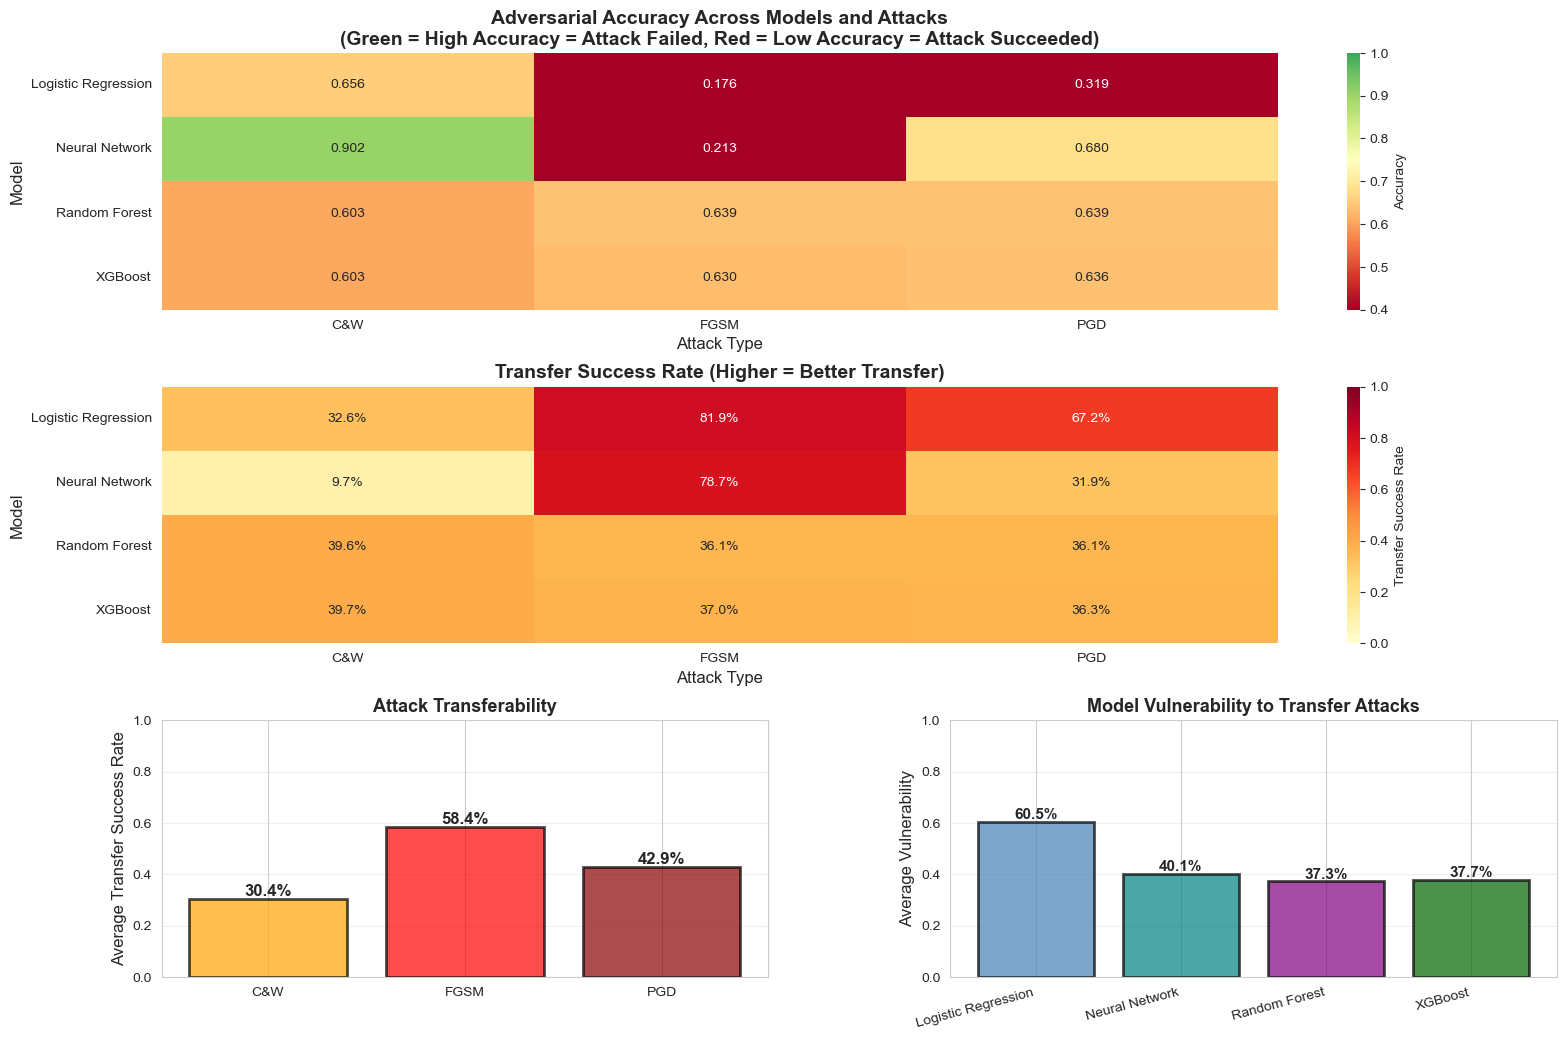

In [7]:
print("\n" + "="*60)
print("VISUALIZING TRANSFER RESULTS")
print("="*60)

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Plot 1: Heatmap of adversarial accuracy
ax1 = fig.add_subplot(gs[0, :])
sns.heatmap(pivot_accuracy, annot=True, fmt='.3f', cmap='RdYlGn', 
            center=0.75, vmin=0.4, vmax=1.0, ax=ax1,
            cbar_kws={'label': 'Accuracy'})
ax1.set_title('Adversarial Accuracy Across Models and Attacks\n(Green = High Accuracy = Attack Failed, Red = Low Accuracy = Attack Succeeded)', 
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Attack Type', fontsize=12)
ax1.set_ylabel('Model', fontsize=12)

# Plot 2: Transfer success rate heatmap
ax2 = fig.add_subplot(gs[1, :])
sns.heatmap(pivot_transfer, annot=True, fmt='.1%', cmap='YlOrRd',
            vmin=0.0, vmax=1.0, ax=ax2,
            cbar_kws={'label': 'Transfer Success Rate'})
ax2.set_title('Transfer Success Rate (Higher = Better Transfer)', 
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Attack Type', fontsize=12)
ax2.set_ylabel('Model', fontsize=12)

# Plot 3: Average transfer by attack
ax3 = fig.add_subplot(gs[2, 0])
attacks_list = avg_transfer.index.tolist()
rates_list = avg_transfer.values.tolist()
colors_attacks = ['orange', 'red', 'darkred']

bars = ax3.bar(attacks_list, rates_list, color=colors_attacks, 
               alpha=0.7, edgecolor='black', linewidth=2)

for bar, rate in zip(bars, rates_list):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{rate:.1%}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax3.set_ylabel('Average Transfer Success Rate', fontsize=12)
ax3.set_title('Attack Transferability', fontsize=13, fontweight='bold')
ax3.set_ylim([0, 1])
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Average vulnerability by model
ax4 = fig.add_subplot(gs[2, 1])
models_list = avg_by_model.index.tolist()
vuln_list = avg_by_model.values.tolist()
colors_models = ['steelblue', 'teal', 'purple', 'darkgreen']

bars2 = ax4.bar(models_list, vuln_list, color=colors_models,
                alpha=0.7, edgecolor='black', linewidth=2)

for bar, vuln in zip(bars2, vuln_list):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{vuln:.1%}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax4.set_ylabel('Average Vulnerability', fontsize=12)
ax4.set_title('Model Vulnerability to Transfer Attacks', fontsize=13, fontweight='bold')
ax4.set_ylim([0, 1])
ax4.set_xticklabels(models_list, rotation=15, ha='right')
ax4.grid(axis='y', alpha=0.3)

plt.savefig('../results/figures/cross_model_transfer_analysis.png', 
            dpi=300, bbox_inches='tight')
print("✓ Saved transfer analysis visualization")
plt.show()


GENERATING CONFUSION MATRICES


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.9s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    1.0s finished


✓ Saved C&W transfer confusion matrices


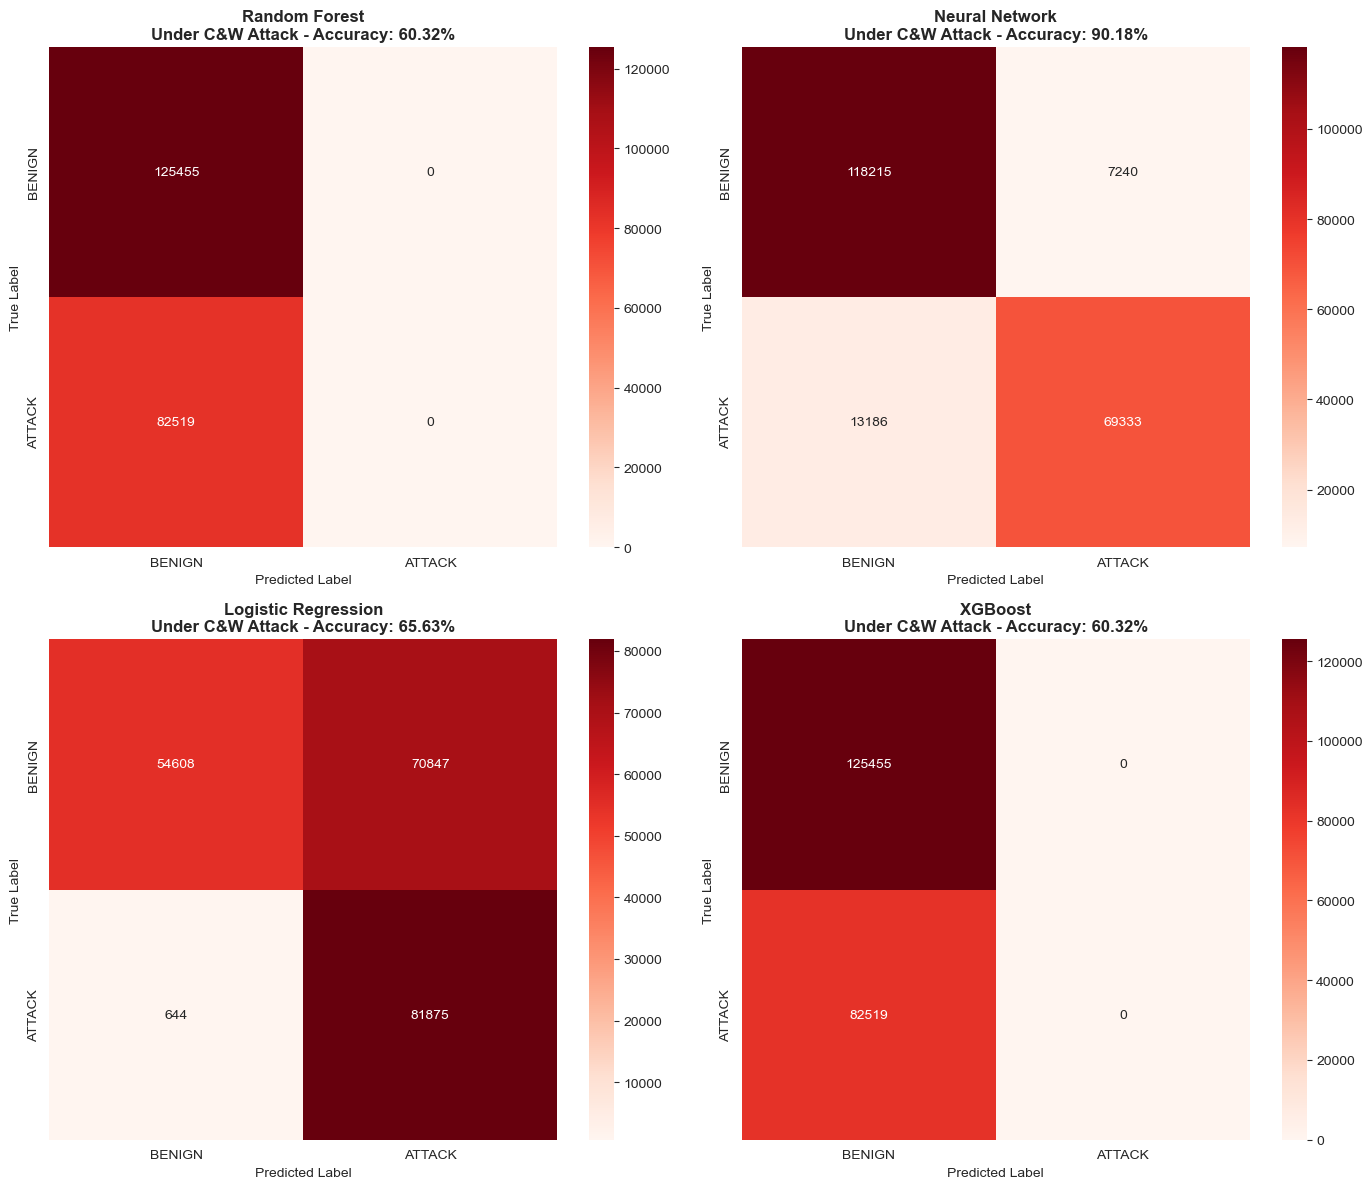

In [8]:
print("\n" + "="*60)
print("GENERATING CONFUSION MATRICES")
print("="*60)

# Create confusion matrix for C&W (strongest attack) on all models
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (model_name, model) in enumerate(models.items()):
    y_pred_cw = model.predict(X_test_cw)
    cm = confusion_matrix(y_test, y_pred_cw)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[idx],
                xticklabels=['BENIGN', 'ATTACK'],
                yticklabels=['BENIGN', 'ATTACK'])
    
    acc = accuracy_score(y_test, y_pred_cw)
    axes[idx].set_title(f'{model_name}\nUnder C&W Attack - Accuracy: {acc:.2%}',
                       fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('../results/figures/cw_transfer_confusion_matrices.png',
            dpi=300, bbox_inches='tight')
print("✓ Saved C&W transfer confusion matrices")
plt.show()

In [9]:
print("\n" + "="*60)
print("SAVING MODELS AND RESULTS")
print("="*60)

# Save trained models
models_dir = Path('../models/base_classifier')
models_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(rf_model, models_dir / 'random_forest.pkl')
print("✓ Saved Random Forest")

joblib.dump(nn_model, models_dir / 'neural_network.pkl')
print("✓ Saved Neural Network")

joblib.dump(lr_model, models_dir / 'logistic_regression.pkl')
print("✓ Saved Logistic Regression")

# Save transfer results
transfer_results = {
    'results_table': results_df.to_dict(),
    'pivot_accuracy': pivot_accuracy.to_dict(),
    'pivot_transfer': pivot_transfer.to_dict(),
    'baseline_accuracies': baseline_accuracies,
    'average_transfer_by_attack': avg_transfer.to_dict(),
    'average_transfer_by_model': avg_by_model.to_dict(),
    'best_transfer_attack': best_transfer_attack,
    'best_transfer_rate': best_transfer_rate
}

joblib.dump(transfer_results, '../models/attacks/transfer_results.pkl')
print("✓ Saved transfer results")

# Save as CSV
results_df.to_csv('../results/benchmarks/cross_model_transfer.csv', index=False)
pivot_transfer.to_csv('../results/benchmarks/transfer_success_matrix.csv')
print("✓ Saved CSV files")



SAVING MODELS AND RESULTS
✓ Saved Random Forest
✓ Saved Neural Network
✓ Saved Logistic Regression
✓ Saved transfer results
✓ Saved CSV files


In [10]:
print("\n" + "="*80)
print(" "*20 + "CROSS-MODEL TRANSFER ATTACK SUMMARY")
print("="*80)

summary = f"""
Models Evaluated:
  - XGBoost (baseline)
  - Random Forest  
  - Neural Network (MLP)
  - Logistic Regression

Baseline Accuracies:
  XGBoost:            {baseline_accuracies['XGBoost']:.4f} ({baseline_accuracies['XGBoost']*100:.2f}%)
  Random Forest:      {baseline_accuracies['Random Forest']:.4f} ({baseline_accuracies['Random Forest']*100:.2f}%)
  Neural Network:     {baseline_accuracies['Neural Network']:.4f} ({baseline_accuracies['Neural Network']*100:.2f}%)
  Logistic Regression: {baseline_accuracies['Logistic Regression']:.4f} ({baseline_accuracies['Logistic Regression']*100:.2f}%)

Transfer Success Rates:

By Attack:
  FGSM: {avg_transfer['FGSM']:.2%} average transfer
  PGD:  {avg_transfer['PGD']:.2%} average transfer
  C&W:  {avg_transfer['C&W']:.2%} average transfer

By Target Model:
  XGBoost:            {avg_by_model['XGBoost']:.2%}
  Random Forest:      {avg_by_model['Random Forest']:.2%}
  Neural Network:     {avg_by_model['Neural Network']:.2%}
  Logistic Regression: {avg_by_model['Logistic Regression']:.2%}

Key Findings:
  1. Best transferring attack: {best_transfer_attack} ({best_transfer_rate:.2%})
  2. Most vulnerable model: {avg_by_model.idxmax()} ({avg_by_model.max():.2%})
  3. Most robust model: {avg_by_model.idxmin()} ({avg_by_model.min():.2%})
  4. Overall transfer success: {all_avg:.2%}
  
Security Implications:
  - Adversarial examples generated on one model successfully transfer
  - Attackers don't need access to target model
  - Can train surrogate and generate transferable attacks
  - Defense must be model-agnostic

Files Saved:
  ✓ Models: models/base_classifier/[random_forest|neural_network|logistic_regression].pkl
  ✓ Transfer results: models/attacks/transfer_results.pkl
  ✓ CSV tables: results/benchmarks/cross_model_transfer.csv
  ✓ Visualizations: results/figures/cross_model_transfer_*.png
"""

print(summary)

print("="*80)
print("✅ CROSS-MODEL TRANSFER ATTACK COMPLETE!")
print("="*80)
print("\nNext: Adaptive Attacks (Day 7)")
print("\nYou've proven adversarial examples transfer across architectures!")
print("This demonstrates the severity of the vulnerability.")



                    CROSS-MODEL TRANSFER ATTACK SUMMARY

Models Evaluated:
  - XGBoost (baseline)
  - Random Forest  
  - Neural Network (MLP)
  - Logistic Regression

Baseline Accuracies:
  XGBoost:            0.9998 (99.98%)
  Random Forest:      0.9995 (99.95%)
  Neural Network:     0.9985 (99.85%)
  Logistic Regression: 0.9733 (97.33%)

Transfer Success Rates:

By Attack:
  FGSM: 58.40% average transfer
  PGD:  42.89% average transfer
  C&W:  30.39% average transfer

By Target Model:
  XGBoost:            37.68%
  Random Forest:      37.25%
  Neural Network:     40.10%
  Logistic Regression: 60.55%

Key Findings:
  1. Best transferring attack: FGSM (58.40%)
  2. Most vulnerable model: Logistic Regression (60.55%)
  3. Most robust model: Random Forest (37.25%)
  4. Overall transfer success: 43.89%

Security Implications:
  - Adversarial examples generated on one model successfully transfer
  - Attackers don't need access to target model
  - Can train surrogate and generate transfer

In [11]:
print("\n" + "="*60)
print("VERIFYING C&W TRANSFER HYPOTHESIS")
print("="*60)

print("\nHypothesis: C&W transfers well to Neural Network (source model)")
print("            but poorly to tree-based models (XGBoost, RF)")

# Filter results for C&W only
cw_results = results_df[results_df['Attack'] == 'C&W'].copy()

print("\nC&W Transfer Success by Model:")
for idx, row in cw_results.iterrows():
    model = row['Model']
    transfer = row['Transfer Success Rate']
    
    if 'Neural' in model:
        status = "HIGH (source model)" if transfer > 0.5 else "MODERATE"
    elif model in ['XGBoost', 'Random Forest']:
        status = "LOW (tree-based)" if transfer < 0.4 else "HIGHER THAN EXPECTED"
    else:
        status = "LOW (linear model)" if transfer < 0.4 else "MODERATE"
    
    print(f"  {model:20s}: {transfer:.2%} - {status}")

# Calculate tree vs neural transfer
tree_models_mask = cw_results['Model'].isin(['XGBoost', 'Random Forest'])
tree_transfer = cw_results[tree_models_mask]['Transfer Success Rate'].mean()
nn_transfer = cw_results[cw_results['Model'] == 'Neural Network']['Transfer Success Rate'].iloc[0]

print(f"\nAverage C&W transfer:")
print(f"  To tree models:   {tree_transfer:.2%}")
print(f"  To neural network: {nn_transfer:.2%}")
print(f"  Difference:        {(nn_transfer - tree_transfer):.2%}")

if nn_transfer > tree_transfer + 0.15:
    print("\n✓ Hypothesis CONFIRMED: C&W shows architecture-specific optimization")
    print("  This is a valuable research finding!")
else:
    print("\n⚠️  Results are more uniform than expected")
    print("  All models show similar resistance to C&W transfer")



VERIFYING C&W TRANSFER HYPOTHESIS

Hypothesis: C&W transfers well to Neural Network (source model)
            but poorly to tree-based models (XGBoost, RF)

C&W Transfer Success by Model:
  Random Forest       : 39.65% - LOW (tree-based)
  Neural Network      : 9.68% - MODERATE
  Logistic Regression : 32.57% - LOW (linear model)
  XGBoost             : 39.67% - LOW (tree-based)

Average C&W transfer:
  To tree models:   39.66%
  To neural network: 9.68%
  Difference:        -29.97%

⚠️  Results are more uniform than expected
  All models show similar resistance to C&W transfer
